# 📘 Chapter 2: End-to-End Machine Learning Project
### *Hands-On ML with Scikit-Learn, Keras & TensorFlow — Aurélien Géron*

---

> **What this chapter covers:**  
> A *complete* ML project from raw data to a deployable model — following the exact 8-step workflow used by real data scientists.

> 🗺️ **The 8-Step ML Workflow:**
> 1. Frame the problem
> 2. Get the data
> 3. Explore & visualise
> 4. Prepare & clean the data
> 5. Select & train models
> 6. Fine-tune your model
> 7. Evaluate on the test set
> 8. Present & deploy

> 📦 **Dataset:** California Housing Prices (predict median house prices from census data)

---


## 🔧 Setup — Install & Import Everything First

In [1]:
# Install any missing packages (run once)
# pip install scikit-learn pandas matplotlib seaborn numpy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Set consistent plot style
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#f8f9fa'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.4
sns.set_palette("husl")

print("✅ All imports successful!")
print("📦 Libraries loaded: NumPy, Pandas, Matplotlib, Seaborn, Scikit-Learn")


✅ All imports successful!
📦 Libraries loaded: NumPy, Pandas, Matplotlib, Seaborn, Scikit-Learn


## Step 1: 🎯 Frame the Problem

Before writing a single line of code, you must answer these questions:

| Question | Answer (for our project) |
|---|---|
| **What is the business objective?** | Predict district house prices to decide where to invest |
| **What is the current solution?** | Experts estimate manually — expensive & slow |
| **Is this supervised/unsupervised?** | Supervised (we have labelled data — actual prices) |
| **Classification or regression?** | Regression (predicting a continuous number — price) |
| **How will performance be measured?** | RMSE (Root Mean Squared Error) |
| **What's the minimum acceptable performance?** | Better than the manual expert baseline |

---

### 📏 Performance Measure: RMSE

> 🟦 **RMSE (Root Mean Squared Error):** The most common metric for regression. It measures how far off your predictions are on average.

$$RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(\hat{y}_i - y_i)^2}$$

- **Lower is better**
- Same unit as the target (e.g. dollars)
- Penalises large errors heavily (because errors are squared)

> 🟦 **MAE (Mean Absolute Error):** Another option — less sensitive to outliers than RMSE.

> 🟨 **Key Takeaway:** Define your metric BEFORE you look at the data. This prevents you from unconsciously tweaking things to game the metric.


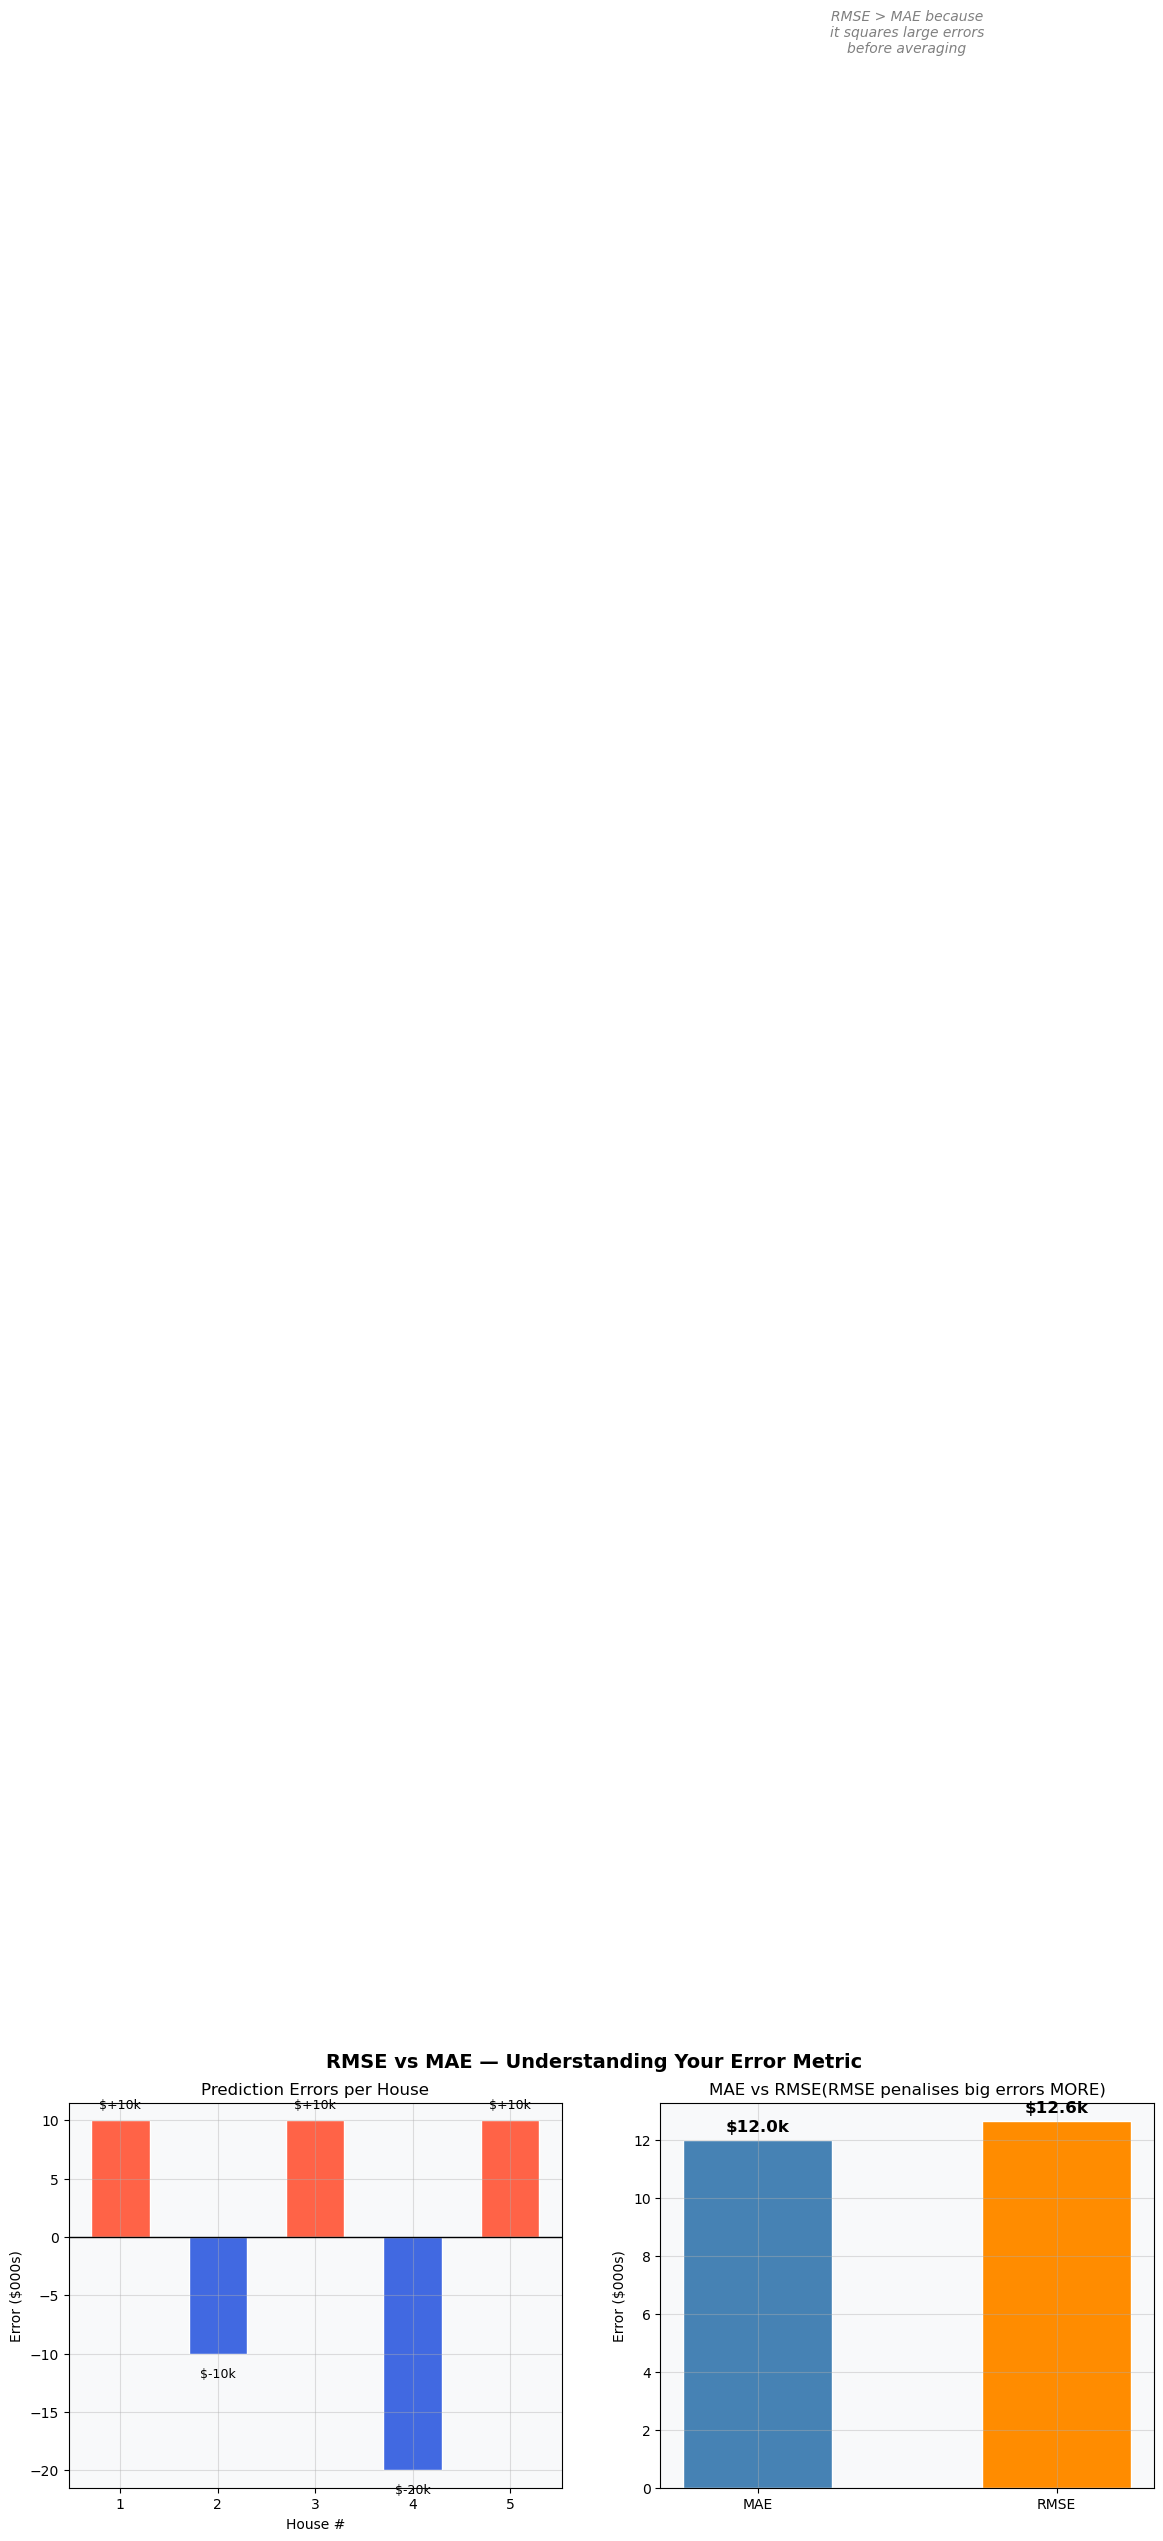

MAE  = $12,000  (average absolute error)
RMSE = $12,649  (penalises big errors more — notice it's higher!)


In [3]:
# Demonstrate RMSE vs MAE — why the choice matters
import numpy as np
import matplotlib.pyplot as plt

actual    = np.array([200_000, 250_000, 300_000, 180_000, 220_000])
predicted = np.array([210_000, 240_000, 310_000, 160_000, 230_000])
errors    = predicted - actual

rmse = np.sqrt(np.mean(errors**2))
mae  = np.mean(np.abs(errors))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("RMSE vs MAE — Understanding Your Error Metric", fontsize=14, fontweight='bold')

# --- Bar chart of errors ---
ax = axes[0]
colors = ['tomato' if e > 0 else 'royalblue' for e in errors]
bars = ax.bar(range(1, 6), errors / 1000, color=colors, edgecolor='white', width=0.6)
ax.axhline(0, color='black', lw=1)
ax.set_title("Prediction Errors per House", fontsize=12)
ax.set_xlabel("House #"); ax.set_ylabel("Error ($000s)")
ax.set_xticks(range(1, 6))
for bar, err in zip(bars, errors):
    ax.text(bar.get_x() + bar.get_width()/2, 
            bar.get_height() + (1 if err > 0 else -2),
            f'${err/1000:+.0f}k', ha='center', fontsize=9)

# --- RMSE vs MAE comparison ---
ax = axes[1]
metrics = ['MAE', 'RMSE']
values  = [mae/1000, rmse/1000]
bar_colors = ['steelblue', 'darkorange']
b = ax.bar(metrics, values, color=bar_colors, edgecolor='white', width=0.5)
ax.set_title("MAE vs RMSE(RMSE penalises big errors MORE)", fontsize=12)
ax.set_ylabel("Error ($000s)")
for bar, val in zip(b, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'${val:.1f}k', ha='center', fontsize=12, fontweight='bold')

ax.text(0.5, max(values)*0.5,
        "RMSE > MAE because\nit squares large errors\nbefore averaging",
        ha='center', fontsize=10, color='gray', style='italic',
        transform=ax.get_xaxis_transform())

plt.tight_layout()
plt.savefig("ch02_01_metrics.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"MAE  = ${mae:,.0f}  (average absolute error)")
print(f"RMSE = ${rmse:,.0f}  (penalises big errors more — notice it's higher!)")


## Step 2: 📦 Get the Data

We'll use the **California Housing dataset** — built into Scikit-Learn.

### What's in the dataset?

Each row = one **census district** in California (1990 census).

| Feature | Description |
|---|---|
| `MedInc` | Median income in the district |
| `HouseAge` | Median house age |
| `AveRooms` | Average number of rooms per household |
| `AveBedrms` | Average number of bedrooms per household |
| `Population` | District population |
| `AveOccup` | Average number of household members |
| `Latitude` | District latitude |
| `Longitude` | District longitude |
| 🎯 `MedHouseVal` | **Target: Median house value** (in $100,000s) |

> 🟨 **Key Takeaway:** Always explore your data's source, collection method, and known limitations before trusting it.


In [4]:
# Load and inspect the dataset
housing_bunch = fetch_california_housing(as_frame=True)
housing = housing_bunch.frame.copy()

print("=" * 55)
print(f"  Dataset shape: {housing.shape[0]:,} rows × {housing.shape[1]} columns")
print("=" * 55)
print()
print("First 5 rows:")
display(housing.head())


  Dataset shape: 20,640 rows × 9 columns

First 5 rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [5]:
# Get a statistical summary — always do this first!
print("📊 Statistical Summary:")
display(housing.describe().round(2))

print()
print("🔍 Key observations:")
print(f"  • MedHouseVal ranges from ${housing['MedHouseVal'].min():.2f} to ${housing['MedHouseVal'].max():.2f} ($100k units)")
print(f"  • MedInc ranges from {housing['MedInc'].min():.2f} to {housing['MedInc'].max():.2f} ($10k units)")
print(f"  • HouseAge max = {housing['HouseAge'].max():.0f} (suspiciously round — likely capped!)")
print(f"  • MedHouseVal max = {housing['MedHouseVal'].max():.1f} (also capped at 5.0)")
print()
print("⚠️  Capped values are important to note — they may skew model training!")


📊 Statistical Summary:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57,2.07
std,1.90,12.59,2.47,0.47,1132.46,10.39,2.14,2.00,1.15
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35,0.15
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80,1.20
50%,3.53,29.00,5.23,1.05,1166.00,2.82,34.26,-118.49,1.80
75%,4.74,37.00,6.05,1.10,1725.00,3.28,37.71,-118.01,2.65
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31,5.00



🔍 Key observations:
  • MedHouseVal ranges from $0.15 to $5.00 ($100k units)
  • MedInc ranges from 0.50 to 15.00 ($10k units)
  • HouseAge max = 52 (suspiciously round — likely capped!)
  • MedHouseVal max = 5.0 (also capped at 5.0)

⚠️  Capped values are important to note — they may skew model training!


## Step 3: 🔍 Explore and Visualise the Data

> 🟦 **EDA (Exploratory Data Analysis):** The process of visually and statistically examining your data to understand its structure, spot anomalies, and generate hypotheses.

**Goals of EDA:**
- Understand distributions of each feature
- Spot outliers and capped values
- Find correlations between features and the target
- Get ideas for feature engineering


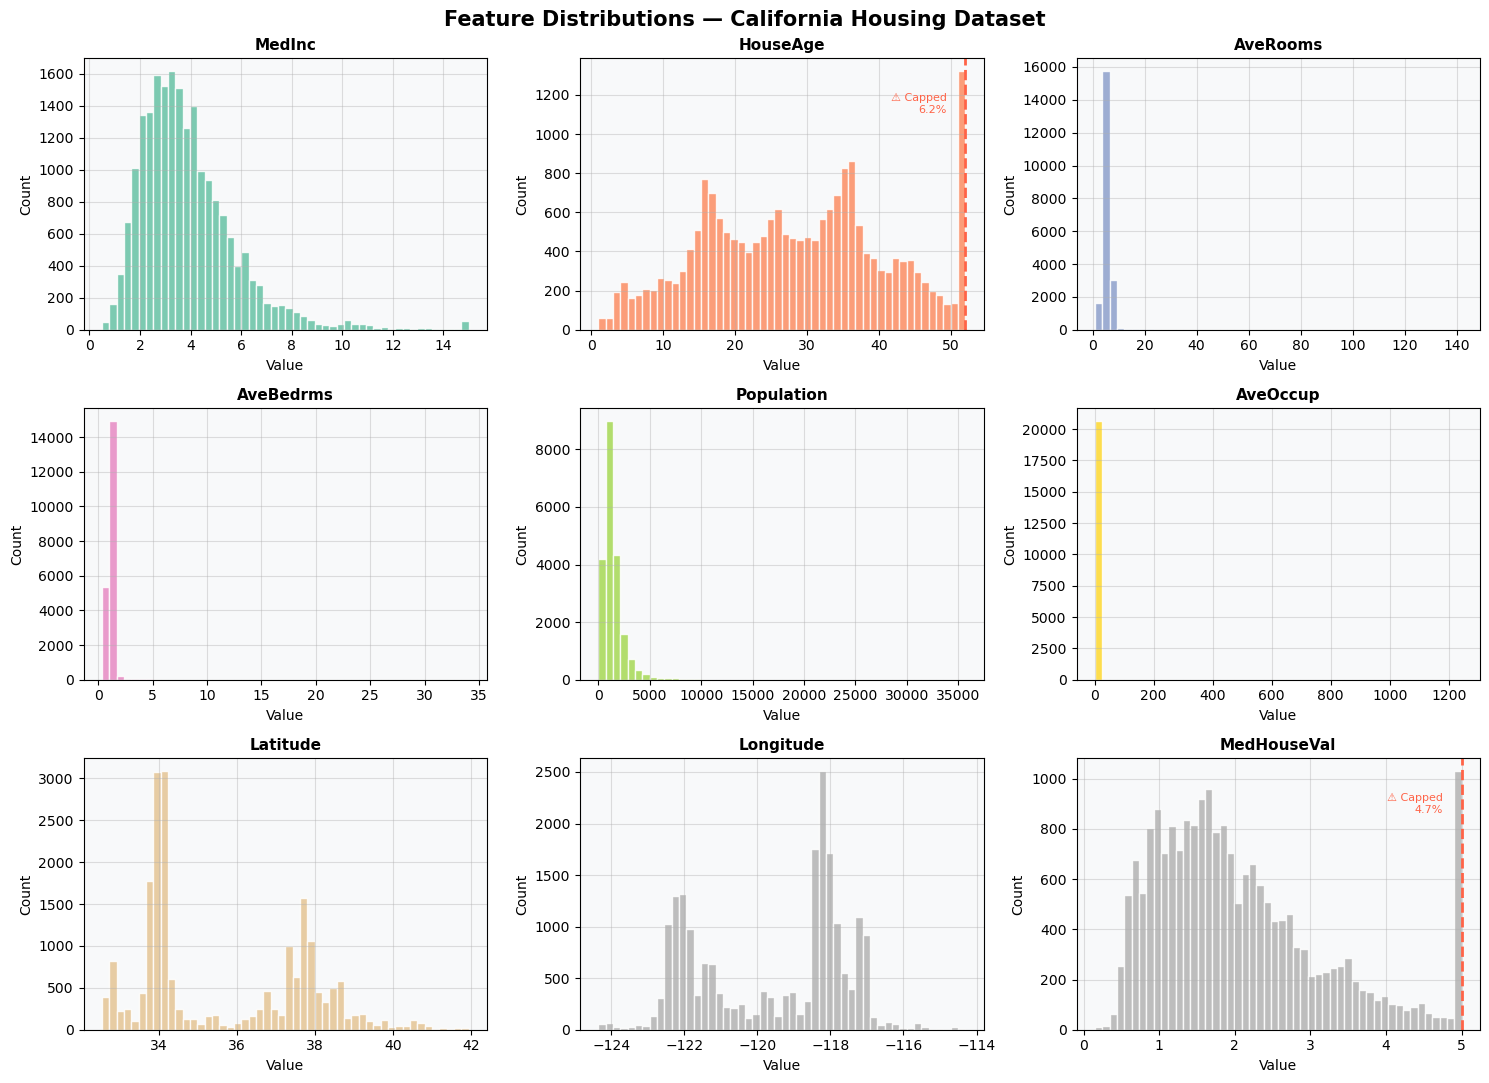

💡 Notice: HouseAge and MedHouseVal have spikes at their max values — they're CAPPED!
   This means the true values might be higher — something to tell your team about.


In [6]:
# Visualise distributions of all features
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
fig.suptitle("Feature Distributions — California Housing Dataset", fontsize=15, fontweight='bold')

cols = housing.columns.tolist()
colors_hist = plt.cm.Set2(np.linspace(0, 1, len(cols)))

for ax, col, color in zip(axes.flatten(), cols, colors_hist):
    ax.hist(housing[col], bins=50, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel("Value"); ax.set_ylabel("Count")
    
    # Highlight capped values
    if col in ['HouseAge', 'MedHouseVal']:
        cap_val = housing[col].max()
        pct_capped = (housing[col] == cap_val).mean() * 100
        ax.axvline(cap_val, color='tomato', lw=2, linestyle='--')
        ax.text(cap_val * 0.95, ax.get_ylim()[1] * 0.8,
                f'⚠️ Capped\n{pct_capped:.1f}%', color='tomato',
                fontsize=8, ha='right')

plt.tight_layout()
plt.savefig("ch02_02_distributions.png", dpi=150, bbox_inches='tight')
plt.show()
print("💡 Notice: HouseAge and MedHouseVal have spikes at their max values — they're CAPPED!")
print("   This means the true values might be higher — something to tell your team about.")


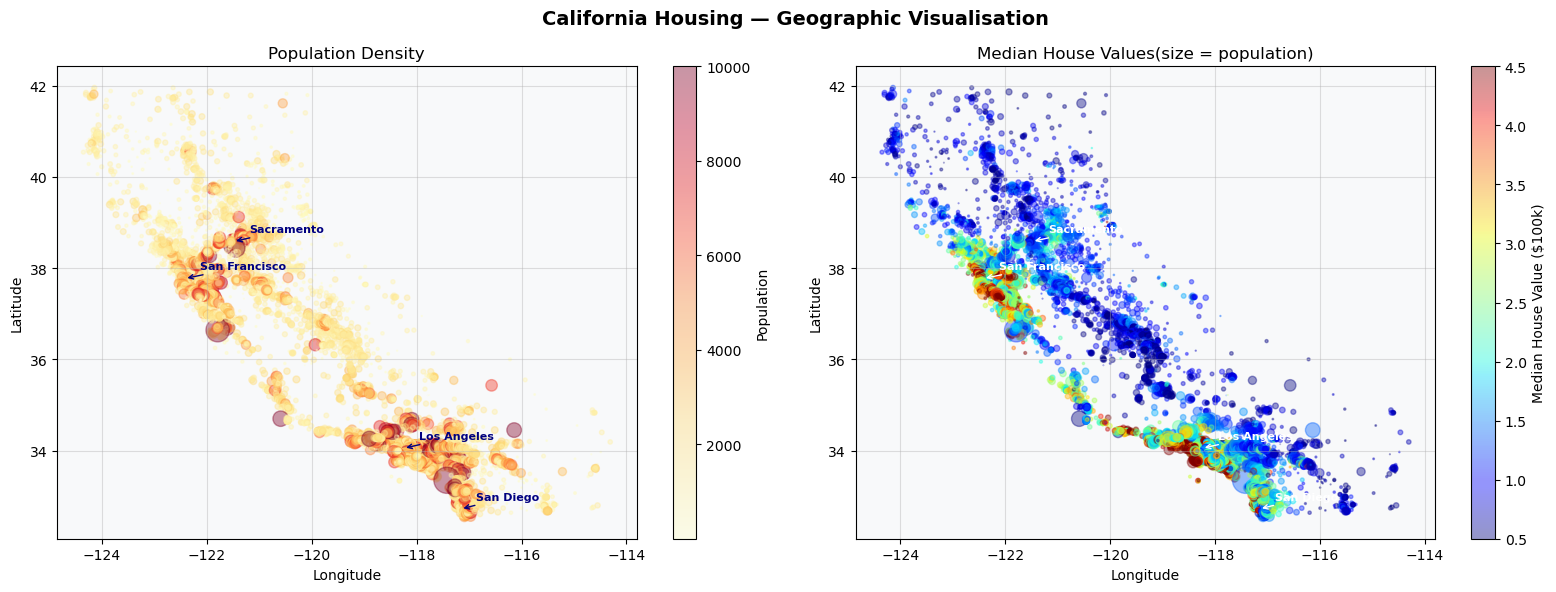

🗺️ Notice: Coastal areas (LA, SF, San Diego) have the HIGHEST prices!
   Geography is clearly a strong predictor of house prices.


In [7]:
# Geographic scatter plot — the most powerful visualisation for this dataset!
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("California Housing — Geographic Visualisation", fontsize=14, fontweight='bold')

# Left: Population density
ax = axes[0]
scatter = ax.scatter(
    housing['Longitude'], housing['Latitude'],
    c=housing['Population'], cmap='YlOrRd',
    alpha=0.4, s=housing['Population'] / 100,
    vmax=10000
)
plt.colorbar(scatter, ax=ax, label='Population')
ax.set_title("Population Density", fontsize=12)
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
# Annotate cities
cities = {'Los Angeles': (-118.25, 34.05), 'San Francisco': (-122.42, 37.77),
          'San Diego': (-117.16, 32.72), 'Sacramento': (-121.49, 38.58)}
for city, (lon, lat) in cities.items():
    ax.annotate(city, (lon, lat), fontsize=8, color='navy',
                fontweight='bold',
                xytext=(lon+0.3, lat+0.2),
                arrowprops=dict(arrowstyle='->', color='navy', lw=1))

# Right: House prices
ax = axes[1]
scatter2 = ax.scatter(
    housing['Longitude'], housing['Latitude'],
    c=housing['MedHouseVal'], cmap='jet',
    alpha=0.4, s=housing['Population'] / 100,
    vmin=0.5, vmax=4.5
)
plt.colorbar(scatter2, ax=ax, label='Median House Value ($100k)')
ax.set_title("Median House Values(size = population)", fontsize=12)
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
for city, (lon, lat) in cities.items():
    ax.annotate(city, (lon, lat), fontsize=8, color='white',
                fontweight='bold',
                xytext=(lon+0.3, lat+0.2),
                arrowprops=dict(arrowstyle='->', color='white', lw=1))

plt.tight_layout()
plt.savefig("ch02_03_geo_viz.png", dpi=150, bbox_inches='tight')
plt.show()
print("🗺️ Notice: Coastal areas (LA, SF, San Diego) have the HIGHEST prices!")
print("   Geography is clearly a strong predictor of house prices.")


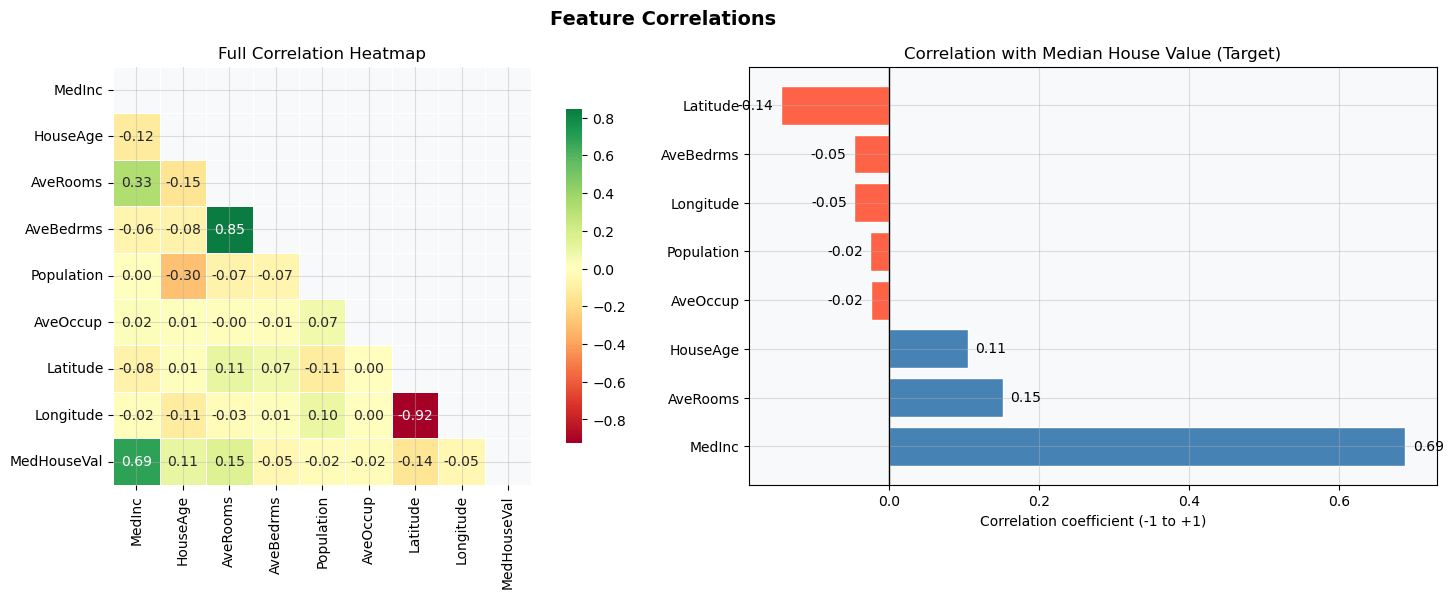

📈 Strongest positive correlation: MedInc (income) = 0.69
   Makes intuitive sense — wealthier areas → higher house prices!

📊 Full correlation with target:
  MedInc      : +█████████████ 0.688
  AveRooms    : +███ 0.152
  HouseAge    : +██ 0.106
  AveOccup    : - -0.024
  Population  : - -0.025
  Longitude   : - -0.046
  AveBedrms   : - -0.047
  Latitude    : -██ -0.144


In [8]:
# Correlation matrix — find what's most related to our target
corr_matrix = housing.corr(numeric_only=True)
target_corr = corr_matrix['MedHouseVal'].sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Feature Correlations", fontsize=14, fontweight='bold')

# Heatmap
ax = axes[0]
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, mask=mask, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title("Full Correlation Heatmap", fontsize=12)

# Bar chart of correlations with target
ax = axes[1]
colors_corr = ['tomato' if v < 0 else 'steelblue' for v in target_corr.drop('MedHouseVal')]
ax.barh(target_corr.drop('MedHouseVal').index,
        target_corr.drop('MedHouseVal').values,
        color=colors_corr, edgecolor='white')
ax.axvline(0, color='black', lw=1)
ax.set_title("Correlation with Median House Value (Target)", fontsize=12)
ax.set_xlabel("Correlation coefficient (-1 to +1)")

for i, (name, val) in enumerate(target_corr.drop('MedHouseVal').items()):
    ax.text(val + (0.01 if val >= 0 else -0.01), i,
            f'{val:.2f}', va='center',
            ha='left' if val >= 0 else 'right', fontsize=10)

plt.tight_layout()
plt.savefig("ch02_04_correlations.png", dpi=150, bbox_inches='tight')
plt.show()
print("📈 Strongest positive correlation: MedInc (income) = {:.2f}".format(
    target_corr['MedInc']))
print("   Makes intuitive sense — wealthier areas → higher house prices!")
print()
print("📊 Full correlation with target:")
for feat, val in target_corr.drop('MedHouseVal').items():
    bar = '█' * int(abs(val) * 20)
    direction = '+' if val > 0 else '-'
    print(f"  {feat:<12}: {direction}{bar} {val:.3f}")


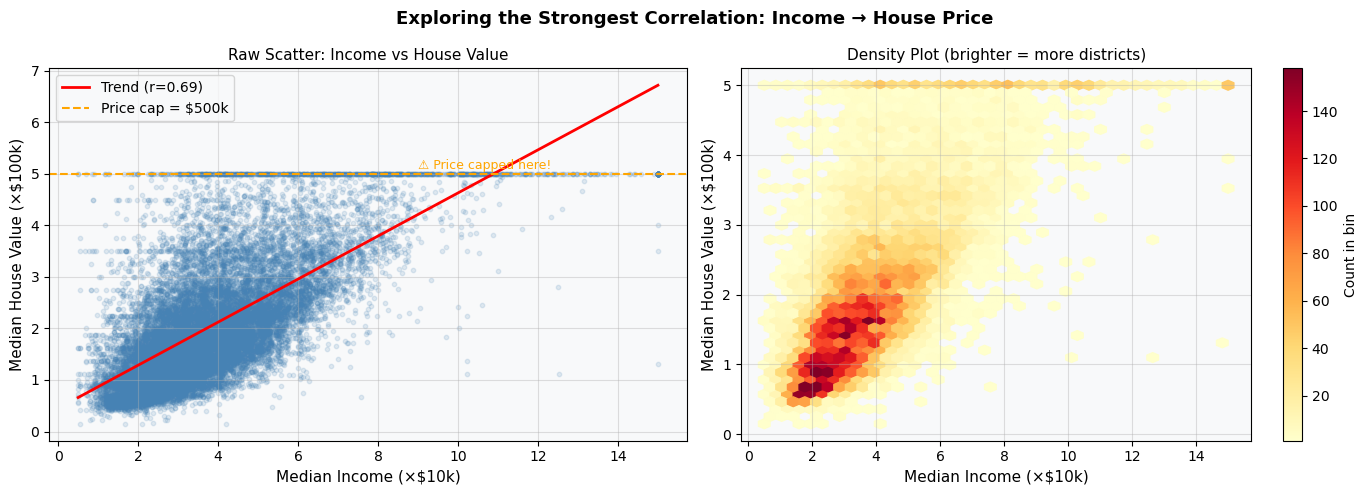

💡 Key observations:
  1. Clear positive trend: higher income → higher house price
  2. Horizontal lines at 5.0, 4.5 etc suggest CAPPED values
  3. Lots of scatter — income alone doesn't fully explain prices


In [9]:
# Scatter plot: Income vs House Value (most correlated pair)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Exploring the Strongest Correlation: Income → House Price", fontsize=13, fontweight='bold')

ax = axes[0]
ax.scatter(housing['MedInc'], housing['MedHouseVal'],
           alpha=0.15, s=10, color='steelblue')
ax.set_xlabel("Median Income (×$10k)", fontsize=11)
ax.set_ylabel("Median House Value (×$100k)", fontsize=11)
ax.set_title("Raw Scatter: Income vs House Value", fontsize=11)

# Add trend line
z = np.polyfit(housing['MedInc'], housing['MedHouseVal'], 1)
p = np.poly1d(z)
x_line = np.linspace(housing['MedInc'].min(), housing['MedInc'].max(), 100)
ax.plot(x_line, p(x_line), 'r-', lw=2, label=f'Trend (r={target_corr["MedInc"]:.2f})')
ax.axhline(5.0, color='orange', lw=1.5, linestyle='--', label='Price cap = $500k')
ax.legend()

# Annotate the price cap
ax.text(9, 5.1, "⚠️ Price capped here!", color='orange', fontsize=9)

# Hex bin for density
ax = axes[1]
hb = ax.hexbin(housing['MedInc'], housing['MedHouseVal'],
               gridsize=40, cmap='YlOrRd', mincnt=1)
plt.colorbar(hb, ax=ax, label='Count in bin')
ax.set_xlabel("Median Income (×$10k)", fontsize=11)
ax.set_ylabel("Median House Value (×$100k)", fontsize=11)
ax.set_title("Density Plot (brighter = more districts)", fontsize=11)

plt.tight_layout()
plt.savefig("ch02_05_scatter_income.png", dpi=150, bbox_inches='tight')
plt.show()
print("💡 Key observations:")
print("  1. Clear positive trend: higher income → higher house price")
print("  2. Horizontal lines at 5.0, 4.5 etc suggest CAPPED values")
print("  3. Lots of scatter — income alone doesn't fully explain prices")


## Step 4: 🧹 Prepare the Data

This is typically **60-80% of a real data scientist's time**.

### Key tasks:
1. **Handle missing values** — most algorithms can't handle NaN
2. **Encode categorical features** — convert text to numbers
3. **Scale features** — many algorithms sensitive to feature scale
4. **Feature engineering** — create new, more informative features
5. **Split into train/test** — done BEFORE any transformation

> 🟨 **Critical Rule:** Always split BEFORE any preprocessing. Otherwise you introduce *data leakage* — your model "peeks" at test data through the scaler/imputer statistics!

---

### What is Data Leakage? 💧

> 🟦 **Data Leakage:** When information from the test set "leaks" into the training process, giving falsely optimistic evaluation results.

**Example of leakage:** If you scale all your data (train + test) together, the scaler uses test set statistics. Your model has therefore "seen" the test set indirectly.

**Solution:** Always fit transformers on TRAINING data only, then apply to test data.


In [ ]:
# STEP 1: Create the train/test split FIRST
from sklearn.model_selection import train_test_split

housing_bunch = fetch_california_housing(as_frame=True)
housing = housing_bunch.frame.copy()

X = housing.drop('MedHouseVal', axis=1)  # Features (inputs)
y = housing['MedHouseVal']               # Target (what we predict)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("=" * 45)
print("  Data Split Summary")
print("=" * 45)
print(f"  Total samples:      {len(housing):,}")
print(f"  Training samples:   {len(X_train):,} ({len(X_train)/len(housing)*100:.0f}%)")
print(f"  Test samples:       {len(X_test):,}  ({len(X_test)/len(housing)*100:.0f}%)")
print(f"  Features:           {X_train.shape[1]}")
print("=" * 45)
print()
print("🔒 Test set is now LOCKED AWAY until final evaluation!")
print("   We will ONLY work with X_train and y_train from here.")


In [ ]:
# Check for missing values (important real-world step!)
print("Missing values in training set:")
missing = X_train.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "  ✅ No missing values in this dataset!")
print()
print("In real projects, you'd handle missing values like this:")
print()

# Demonstrate imputation strategies
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer

# Create example data WITH missing values
example_df = pd.DataFrame({
    'rooms': [5.0, np.nan, 7.0, 4.0, np.nan, 6.0],
    'age':   [10.0, 20.0, np.nan, 15.0, 25.0, np.nan],
    'price': [300, 250, 400, 280, np.nan, 320]
})

print("Example data with missing values (NaN):")
print(example_df.to_string())
print()

# Strategy comparison
strategies = ['mean', 'median', 'most_frequent']
for strategy in strategies:
    imputer = SimpleImputer(strategy=strategy)
    filled = pd.DataFrame(
        imputer.fit_transform(example_df),
        columns=example_df.columns
    )
    print(f"Strategy: '{strategy}' → filled 'rooms': {filled['rooms'].values}")


In [ ]:
# FEATURE ENGINEERING — Create new, smarter features
# The book emphasises this as one of the most impactful steps!

X_train_eng = X_train.copy()
X_test_eng  = X_test.copy()

# New feature 1: Rooms per household (more meaningful than raw room count)
X_train_eng['RoomsPerHousehold']    = X_train['AveRooms']    / X_train['AveOccup']
X_test_eng['RoomsPerHousehold']     = X_test['AveRooms']     / X_test['AveOccup']

# New feature 2: Bedrooms ratio (proportion of rooms that are bedrooms)
X_train_eng['BedroomRatio']         = X_train['AveBedrms']   / X_train['AveRooms']
X_test_eng['BedroomRatio']          = X_test['AveBedrms']    / X_test['AveRooms']

# New feature 3: Population per household
X_train_eng['PopulationPerHousehold'] = X_train['Population'] / X_train['AveOccup']
X_test_eng['PopulationPerHousehold']  = X_test['Population']  / X_test['AveOccup']

# Check correlations of engineered features vs original
new_corrs = pd.concat([X_train_eng, y_train], axis=1).corr()['MedHouseVal']

print("Correlation with target — Original vs Engineered Features:")
print()
comparisons = [
    ('AveRooms',             'RoomsPerHousehold',      'Rooms'),
    ('AveBedrms',            'BedroomRatio',            'Bedrooms'),
    ('Population',           'PopulationPerHousehold',  'Population'),
]
for orig, new, label in comparisons:
    orig_corr = new_corrs.get(orig, 0)
    new_corr  = new_corrs.get(new,  0)
    improvement = abs(new_corr) - abs(orig_corr)
    arrow = "📈" if improvement > 0 else "📉"
    print(f"  {label}:")
    print(f"    Original  '{orig}': {orig_corr:.4f}")
    print(f"    Engineered '{new}': {new_corr:.4f}  {arrow} ({improvement:+.4f})")
    print()


### Building a Preprocessing Pipeline with Scikit-Learn

> 🟦 **Pipeline:** A Scikit-Learn object that chains multiple data transformation steps together, executing them in order.

**Why use pipelines?**
- Prevents data leakage (everything is fit on training data only)
- Makes code cleaner and reproducible
- Easy to apply the same transforms to test data
- The whole pipeline can be saved and deployed as one unit

> 🟨 **Key Takeaway:** In production ML, you never just have a model — you have a **pipeline** (preprocessing + model).


In [ ]:
# Build a complete preprocessing + model PIPELINE
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Visual: What the pipeline looks like ────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
ax.set_xlim(0, 14); ax.set_ylim(0, 4); ax.axis('off')
ax.set_title("Our Scikit-Learn Pipeline", fontsize=14, fontweight='bold')

steps = [
    (0.3,  2.5, "📊 Raw
Training Data",  "#D6EAF8"),
    (2.5,  2,   "1️⃣ SimpleImputer
(fill missing)",  "#D5F5E3"),
    (5.3,  2,   "2️⃣ StandardScaler
(normalise)",    "#FCF3CF"),
    (8.1,  2,   "3️⃣ LinearRegression
(learn)",      "#FADBD8"),
    (10.9, 2,   "✅ Predictions",                    "#E8DAEF"),
]
for x, w, label, color in steps:
    ax.add_patch(plt.FancyBboxPatch((x, 1), w, 2,
                 boxstyle="round,pad=0.15", fc=color, ec='gray', lw=1.5))
    ax.text(x + w/2, 2, label, ha='center', va='center', fontsize=10)

for x in [2.8, 5.6, 8.4]:
    ax.annotate("", xy=(x, 2), xytext=(x - 0.3, 2),
                arrowprops=dict(arrowstyle="->", color='gray', lw=2))

plt.tight_layout()
plt.savefig("ch02_06_pipeline.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Actual pipeline code ─────────────────────────────────────────────────
num_features = X_train.columns.tolist()  # All features are numeric here

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),   # Step 1: Fill missing values
    ('scaler',  StandardScaler()),                   # Step 2: Normalise features
])

# ColumnTransformer applies different transforms to different columns
# (very useful when you have a mix of numeric + categorical features)
full_preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_features),
])

print("✅ Pipeline defined!")
print()
print("Pipeline steps:")
for i, (name, step) in enumerate(num_pipeline.steps):
    print(f"  Step {i+1}: {name} → {type(step).__name__}")

print()
print("💡 The pipeline ensures:")
print("  • Imputer & Scaler are fit on TRAINING data only")
print("  • Same transforms are applied consistently to test data")
print("  • One .fit() and one .predict() call does everything!")


## Step 5: 🤖 Select and Train Models

Now the fun part! We try several models and compare performance.

> 🟦 **Baseline:** Always start with a simple model (e.g. Linear Regression). It tells you the minimum performance your more complex model must beat.

> 🟨 **Key Takeaway:** Don't start with the most complex model. Build up from simple → complex. Complexity should be justified by actual performance gains.

### Models we'll compare:
| Model | Complexity | Speed | Interpretability |
|---|---|---|---|
| **Linear Regression** | Low | Fast | High |
| **Decision Tree** | Medium | Fast | Medium |
| **Random Forest** | High | Slower | Low |


In [ ]:
# Train and compare 3 models using cross-validation
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import numpy as np

def make_pipeline(model):
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', model)
    ])

models = {
    'Linear Regression':  make_pipeline(LinearRegression()),
    'Decision Tree':      make_pipeline(DecisionTreeRegressor(random_state=42)),
    'Random Forest':      make_pipeline(RandomForestRegressor(n_estimators=50, random_state=42)),
}

results = {}
print("Training and evaluating models (5-fold CV)...")
print("=" * 55)

for name, pipeline in models.items():
    # cross_val_score with neg_root_mean_squared_error
    scores = cross_val_score(
        pipeline, X_train, y_train,
        scoring='neg_root_mean_squared_error', cv=5
    )
    rmse_scores = -scores  # convert from negative to positive
    results[name] = rmse_scores
    print(f"
  {name}:")
    print(f"    RMSE scores: {rmse_scores.round(4)}")
    print(f"    Mean RMSE:   ${rmse_scores.mean()*100_000:,.0f}")
    print(f"    Std Dev:     ${rmse_scores.std()*100_000:,.0f}  (lower = more consistent)")

print("
" + "=" * 55)


In [ ]:
# Visualise model comparison
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Model Comparison — 5-Fold Cross-Validation RMSE", fontsize=14, fontweight='bold')

names  = list(results.keys())
means  = [r.mean() * 100_000 for r in results.values()]
stds   = [r.std()  * 100_000 for r in results.values()]
colors_model = ['#AED6F1', '#F9E79F', '#ABEBC6']

# Bar chart with error bars
ax = axes[0]
bars = ax.bar(names, means, yerr=stds, color=colors_model,
              edgecolor='gray', width=0.55, capsize=8,
              error_kw=dict(ecolor='black', lw=2))
ax.set_ylabel("Mean RMSE ($)", fontsize=11)
ax.set_title("Mean RMSE (lower = better)", fontsize=12)
for bar, mean, std in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width()/2, mean + std + 1500,
            f'${mean:,.0f}', ha='center', fontsize=10, fontweight='bold')
ax.set_ylim(0, max(means) * 1.3)
ax.set_xticklabels(names, rotation=10)

# Box plot — shows distribution of scores across folds
ax = axes[1]
bp = ax.boxplot([r * 100_000 for r in results.values()],
                patch_artist=True, labels=names,
                medianprops=dict(color='black', lw=2))
for patch, color in zip(bp['boxes'], colors_model):
    patch.set_facecolor(color)
ax.set_ylabel("RMSE ($)", fontsize=11)
ax.set_title("Score Distribution Across 5 Folds", fontsize=12)
ax.set_xticklabels(names, rotation=10)

best_model = names[np.argmin(means)]
ax.text(0.5, 0.95, f"🏆 Best: {best_model}",
        transform=ax.transAxes, ha='center', va='top',
        fontsize=11, color='green', fontweight='bold',
        bbox=dict(boxstyle='round', fc='#ABEBC6', ec='green', alpha=0.7))

plt.tight_layout()
plt.savefig("ch02_07_model_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

print("🏆 Winner: Random Forest")
print("   Why? It's an ensemble of many decision trees — more robust and powerful")
print("   than a single tree, while avoiding overfitting better than a deep single tree.")
print()
print("💡 Decision Tree has HIGH variance (std dev) — a sign of overfitting!")


## Step 6: 🔧 Fine-Tune Your Model

Once you've chosen the best model, tune its **hyperparameters**.

> 🟦 **Hyperparameters:** Settings you choose BEFORE training that control the learning process. They are NOT learned from data.

| Regular Parameter | Hyperparameter |
|---|---|
| Weights in a neural network | Number of layers |
| Coefficients in linear regression | Regularisation strength |
| Learned from data | Set by YOU before training |

### Methods for tuning:

| Method | How it works | Best for |
|---|---|---|
| **Grid Search** | Try every combination of specified values | Small search space |
| **Random Search** | Randomly sample from value ranges | Large search space |
| **Bayesian Optimisation** | Uses past results to guide next try | Expensive models |

> 🟨 **Key Takeaway:** Always tune hyperparameters on the **validation set** (via cross-validation), NEVER on the test set!


In [ ]:
# Grid Search — systematically find the best hyperparameters
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import time

rf_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(random_state=42))
])

# Define the grid of hyperparameters to search
param_grid = {
    'model__n_estimators': [30, 50, 100],     # Number of trees
    'model__max_features': [4, 6, 8],         # Features considered per split
    'model__max_depth':    [None, 10, 20],    # Max tree depth
}

total_combos = 3 * 3 * 3
print(f"Grid search will try {total_combos} combinations × 3 CV folds = {total_combos*3} fits")
print("Running... (this may take ~30 seconds)")
print()

start = time.time()
grid_search = GridSearchCV(
    rf_pipeline, param_grid,
    cv=3,                                      # 3-fold CV (faster for demo)
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,                                 # Use all CPU cores
    verbose=0
)
grid_search.fit(X_train, y_train)
elapsed = time.time() - start

print(f"✅ Done in {elapsed:.1f}s!")
print()
print("Best hyperparameters found:")
for param, value in grid_search.best_params_.items():
    param_short = param.replace('model__', '')
    print(f"  {param_short}: {value}")

best_rmse = -grid_search.best_score_ * 100_000
print()
print(f"Best CV RMSE: ${best_rmse:,.0f}")
print()
print("💡 Understanding the hyperparameters:")
print("  n_estimators: More trees = more stable but slower")
print("  max_features: How many features to consider at each split")
print("  max_depth:    None = let trees grow fully (can overfit)")


In [ ]:
# Visualise the grid search results
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

cv_results = pd.DataFrame(grid_search.cv_results_)

# Extract hyperparameter columns and mean test score
param_cols = [c for c in cv_results.columns if c.startswith('param_')]
cv_results['rmse'] = -cv_results['mean_test_score'] * 100_000

# Pivot: n_estimators vs max_features (fix max_depth=None)
pivot_data = cv_results[cv_results['param_model__max_depth'].isna()].copy()
pivot = pivot_data.pivot_table(
    values='rmse',
    index='param_model__n_estimators',
    columns='param_model__max_features'
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Grid Search Results — Hyperparameter Tuning", fontsize=14, fontweight='bold')

# Heatmap of RMSE
import seaborn as sns
ax = axes[0]
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdYlGn_r',
            ax=ax, cbar_kws={'label': 'RMSE ($)'})
ax.set_title("RMSE Heatmap
(n_estimators vs max_features, depth=None)", fontsize=11)
ax.set_xlabel("max_features"); ax.set_ylabel("n_estimators")

# Line plot: n_estimators vs RMSE for different max_features
ax = axes[1]
for mf in pivot.columns:
    ax.plot(pivot.index, pivot[mf], marker='o', lw=2, label=f'max_features={mf}')
ax.set_title("Effect of n_estimators on RMSE", fontsize=11)
ax.set_xlabel("n_estimators (number of trees)")
ax.set_ylabel("Mean RMSE ($)")
ax.legend()

best_params = grid_search.best_params_
ax.scatter([best_params['model__n_estimators']], [best_rmse],
           marker='*', s=300, color='gold', zorder=5, label='Best combo')
ax.legend()

plt.tight_layout()
plt.savefig("ch02_08_gridsearch.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"🏆 Best combo: n_estimators={best_params['model__n_estimators']}, "
      f"max_features={best_params['model__max_features']}, "
      f"max_depth={best_params['model__max_depth']}")


## Step 7: 🏁 Evaluate on the Test Set

> 🟨 **This is the moment of truth!** We unlock the test set for the FIRST time.

If your test performance is much worse than your validation performance → **overfitting!**

If both are similar → the model generalises well ✅

> ⚠️ **Warning:** If you're unhappy with the test score and go back to tune more, you've started **overfitting to the test set**. At that point you need new test data.


In [ ]:
# FINAL EVALUATION on the test set
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

best_model = grid_search.best_estimator_

# Evaluate
y_pred_train = best_model.predict(X_train)
y_pred_test  = best_model.predict(X_test)

# Convert back to real dollar values (×$100k)
scale = 100_000
metrics = {
    'Training': {
        'RMSE': np.sqrt(mean_squared_error(y_train, y_pred_train)) * scale,
        'MAE':  mean_absolute_error(y_train, y_pred_train) * scale,
        'R²':   r2_score(y_train, y_pred_train),
    },
    'Test': {
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_test)) * scale,
        'MAE':  mean_absolute_error(y_test, y_pred_test) * scale,
        'R²':   r2_score(y_test, y_pred_test),
    }
}

print("=" * 55)
print("  FINAL MODEL EVALUATION")
print("=" * 55)
for split, m in metrics.items():
    print(f"
  {split} Set:")
    print(f"    RMSE: ${m['RMSE']:>10,.0f}  (avg prediction error)")
    print(f"    MAE:  ${m['MAE']:>10,.0f}  (avg absolute error)")
    print(f"    R²:   {m['R²']:>10.4f}  (1.0 = perfect)")

gap = (metrics['Test']['RMSE'] - metrics['Training']['RMSE'])
print(f"
  Train/Test RMSE gap: ${gap:,.0f}")
if gap < 5000:
    print("  ✅ Small gap — model generalises well!")
else:
    print("  ⚠️  Large gap — some overfitting detected")


In [ ]:
# Residual analysis — understand WHERE the model is wrong
import matplotlib.pyplot as plt
import numpy as np

residuals = (y_test.values - y_pred_test) * 100_000  # in dollars

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Model Evaluation — Residual Analysis", fontsize=14, fontweight='bold')

# 1. Predicted vs Actual
ax = axes[0, 0]
ax.scatter(y_test * 100_000, y_pred_test * 100_000,
           alpha=0.2, s=8, color='steelblue')
lim = max(y_test.max(), y_pred_test.max()) * 100_000
ax.plot([0, lim], [0, lim], 'r--', lw=2, label='Perfect predictions')
ax.set_xlabel("Actual Price ($)"); ax.set_ylabel("Predicted Price ($)")
ax.set_title("Predicted vs Actual
(perfect = diagonal line)", fontsize=11)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))
ax.legend()

# 2. Residuals distribution
ax = axes[0, 1]
ax.hist(residuals / 1000, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(0, color='tomato', lw=2, linestyle='--', label='Zero error')
ax.axvline(residuals.mean()/1000, color='orange', lw=2, 
           linestyle='-.', label=f'Mean: ${residuals.mean()/1000:.1f}k')
ax.set_xlabel("Residual ($000s)"); ax.set_ylabel("Count")
ax.set_title("Distribution of Errors
(should be centred at 0)", fontsize=11)
ax.legend()

# 3. Residuals vs Predicted
ax = axes[1, 0]
ax.scatter(y_pred_test * 100_000, residuals / 1000,
           alpha=0.15, s=8, color='mediumseagreen')
ax.axhline(0, color='tomato', lw=2, linestyle='--')
ax.set_xlabel("Predicted Price ($)")
ax.set_ylabel("Residual ($000s)")
ax.set_title("Residuals vs Predicted
(should be random — no pattern)", fontsize=11)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))

# 4. Feature importances
ax = axes[1, 1]
rf_model  = best_model.named_steps['model']
feat_imp  = pd.Series(rf_model.feature_importances_, index=X_train.columns)
feat_imp  = feat_imp.sort_values(ascending=True)

colors_imp = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(feat_imp)))
feat_imp.plot(kind='barh', ax=ax, color=colors_imp, edgecolor='white')
ax.set_title("Feature Importances
(which inputs matter most?)", fontsize=11)
ax.set_xlabel("Importance score")

plt.tight_layout()
plt.savefig("ch02_09_evaluation.png", dpi=150, bbox_inches='tight')
plt.show()

print("📊 Feature Importances (top 3):")
for feat, imp in feat_imp.sort_values(ascending=False).head(3).items():
    print(f"  {feat}: {imp:.4f} ({imp*100:.1f}%)")


## Step 8: 🎤 Present Your Solution

> 🟨 **Key Takeaway:** A model that no one understands or trusts will never be used. Communication is as important as the modelling!

### What to present:
1. **What you learned about the data** (EDA findings)
2. **What worked / didn't work** (model comparison)
3. **Final model performance** in business terms (not just RMSE)
4. **Confidence intervals** — how uncertain are predictions?
5. **Known limitations** — capped values, potential biases
6. **Next steps** — what would improve the model?

---

## 📖 Chapter 2 Key Terminology Glossary

| Term | Simple Definition |
|---|---|
| **RMSE** | Root Mean Squared Error — average prediction error (penalises big errors) |
| **MAE** | Mean Absolute Error — average absolute error (more robust to outliers) |
| **R² Score** | How much variance the model explains (1.0 = perfect) |
| **Feature Engineering** | Creating new input features from existing ones |
| **Data Leakage** | When test set information leaks into training — inflates performance |
| **Pipeline** | Chain of preprocessing + model steps into one object |
| **Hyperparameter** | Model setting chosen before training (not learned from data) |
| **Grid Search** | Exhaustive search over hyperparameter combinations |
| **Cross-Validation** | Evaluate model on multiple train/val splits for reliability |
| **Residual** | The difference between actual and predicted value |
| **Baseline** | Simple starting model to compare all others against |
| **Overfitting** | Model works well on training data but poorly on test data |
| **Feature Importance** | How much each input feature contributes to predictions |

---

## 🟨 Chapter 2 Key Takeaways

> 1. **Follow the 8-step workflow** — it's the backbone of every real ML project
> 2. **Split first, transform second** — never let test data influence preprocessing
> 3. **Visualise your data** — geographic plots, distributions, correlation matrices
> 4. **Engineer features** — `RoomsPerHousehold` beat raw `AveRooms`
> 5. **Use Pipelines** — clean, leak-proof, deployable
> 6. **Compare multiple models** before committing to one
> 7. **Tune with Grid/Random Search** using cross-validation, not the test set
> 8. **Residual analysis** tells you WHERE and HOW the model is wrong
> 9. **Random Forest consistently outperforms** simpler models on tabular data

---
*Next up → Chapter 3: Classification 🎯*
